### Using autograd in PyTorch

In [3]:
import torch

# Create a tensor with requires_grad=True to track computations
t = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# Perform an operation on the tensor, simulating "forward propagation"
tensor_sum = t.sum()

# Run backpropagation
tensor_sum.backward()

# Print the gradient values
t.grad

tensor([1., 1., 1.])

### Data preprocessing for neural networks

In [4]:
import torch
from sklearn import preprocessing
import numpy as np

# Create a sample feature array
features = np.array(
    [
        [-100.1, 3240.1],
        [-200.2, -234.1],
        [5000.5, 150.1],
        [6000.6, -125.1],
        [9000.9, -673.1],
    ]
)
# Create a StandardScaler object
scaler = preprocessing.StandardScaler()

# Transform the features using the scaler
features_standardized = scaler.fit_transform(features)

# Convert the standardized features to a tensor
features_standardized_tensor = torch.tensor(features_standardized.tolist(), dtype=torch.float64)

# Print the standardized feature tensor
features_standardized_tensor

tensor([[-1.1254,  1.9643],
        [-1.1533, -0.5007],
        [ 0.2953, -0.2281],
        [ 0.5739, -0.4234],
        [ 1.4096, -0.8122]], dtype=torch.float64)

In [5]:
# Create a tensor with requires_grad=True to track computations
torch_features = torch.tensor(
    [
        [-100.1, 3240.1],
        [-200.2, -234.1],
        [5000.5, 150.1],
        [6000.6, -125.1],
        [9000.9, -673.1]
    ], requires_grad=True)

# Calculate the mean and standard deviation of the features
mean = torch_features.mean(0, keepdim=True)
standard_deviation = torch_features.std(0, unbiased=False, keepdim=True)

# Standardised features
torch_features_standardized = torch_features - mean

torch_features_standardized /= standard_deviation

# Print the standardised features
torch_features_standardized

tensor([[-1.1254,  1.9643],
        [-1.1533, -0.5007],
        [ 0.2953, -0.2281],
        [ 0.5739, -0.4234],
        [ 1.4096, -0.8122]], grad_fn=<DivBackward0>)

### Development of a neural network

In [6]:
import torch
import torch.nn as nn

# Define a simple neural network model
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 1)
        
    def forward(self, x):
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = nn.functional.sigmoid(self.fc3(x))
        return x
    
# Initialize the neural network, loss criterion, and optimizer
network = SimpleNeuralNet()

# Define the loss criterion and optimizer
loss_criterion = nn.BCELoss()
optimizer = torch.optim.RMSprop(network.parameters())

# Output the network architecture
network

SimpleNeuralNet(
  (fc1): Linear(in_features=10, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
)

### Define a neural network using 'Sequential'

In [7]:
import torch
import torch.nn as nn

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.sequential(x)
        return x
    
# Initialize the neural network, loss criterion, and optimizer
SimpleNeuralNet()

SimpleNeuralNet(
  (sequential): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

### Training a binary classifier

In [8]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import RMSprop
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a synthetic dataset for binary classification
features, target = make_classification(n_classes=2, n_features=10, n_samples=1000)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1)

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.sequential(x)
        return x
    
# Initialize the neural network
network = SimpleNeuralNet()

# Define the loss criterion and optimizer
criterion = nn.BCELoss()
optimizer = RMSprop(network.parameters())

# Define the training data loader
train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Learn neural network parameters using backpropagation
epochs = 3
training_history = {"loss": [], "accuracy": []}
for epoch in range(epochs):
    network.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        train_output = network(x_train)
        epoch_loss = criterion(train_output, y_train).item()
        epoch_accuracy = (train_output.round() == y_train).float().mean().item()
    training_history["loss"].append(epoch_loss)
    training_history["accuracy"].append(epoch_accuracy)
    print(f"Epoch: {epoch + 1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")
        
# Evaluate the model on the test set
network.eval()
with torch.no_grad():
    output = network(x_test)
    test_loss = criterion(output, y_test)
    test_accuracy = (output.round() == y_test).float().mean()
    print(f"Test Loss: {test_loss.item()}, \tTest Accuracy: {test_accuracy.item()}")

Epoch: 1, Loss: 0.1397, Accuracy: 0.9500
Epoch: 2, Loss: 0.1058, Accuracy: 0.9589
Epoch: 3, Loss: 0.0914, Accuracy: 0.9644
Test Loss: 0.06877756863832474, 	Test Accuracy: 0.9700000286102295


### Visualize the neural network

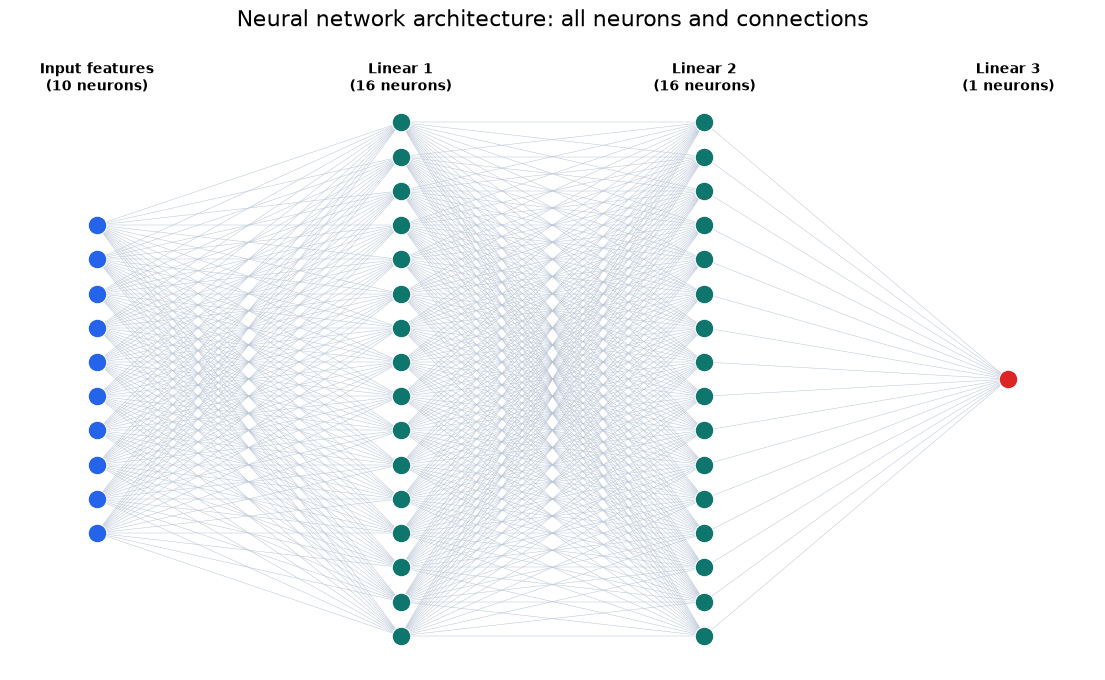

In [9]:
import matplotlib.pyplot as plt


def draw_network(model):
    # Read every Linear layer from the trained model.
    linear_layers = [
        layer for layer in model.modules() if isinstance(layer, torch.nn.Linear)
    ]
    layer_sizes = [linear_layers[0].in_features]
    layer_sizes.extend(layer.out_features for layer in linear_layers)
    layer_names = ["Input features"]
    layer_names.extend(
        f"Linear {index}"
        for index in range(1, len(linear_layers) + 1)
    )

    x_positions = np.linspace(0.08, 0.92, len(layer_sizes))
    max_nodes = max(layer_sizes)
    _, axis = plt.subplots(figsize=(14, 8))
    axis.set_xlim(0, 1)
    axis.set_ylim(0, max_nodes + 2)
    axis.axis("off")

    node_positions = []
    for x_position, layer_size, layer_name in zip(
        x_positions, layer_sizes, layer_names
    ):
        y_positions = np.linspace(
            (max_nodes - layer_size) / 2 + 1,
            (max_nodes + layer_size) / 2,
            layer_size,
        )
        layer_nodes = [(x_position, y_position) for y_position in y_positions]
        node_positions.append(layer_nodes)
        axis.text(
            x_position,
            max_nodes + 1.3,
            f"{layer_name}\n({layer_size} neurons)",
            ha="center",
            va="center",
            weight="bold",
        )

    # Draw every connection between neighboring layers.
    for previous_layer, current_layer in zip(node_positions[:-1], node_positions[1:]):
        for previous_node in previous_layer:
            for current_node in current_layer:
                axis.plot(
                    [previous_node[0], current_node[0]],
                    [previous_node[1], current_node[1]],
                    color="#b8c4d6",
                    linewidth=0.35,
                    zorder=1,
                )

    layer_colors = ["#2563eb", "#0f766e", "#0f766e", "#dc2626"]
    for layer_nodes, color in zip(node_positions, layer_colors):
        for x_position, y_position in layer_nodes:
            axis.scatter(
                x_position,
                y_position,
                s=180,
                color=color,
                edgecolors="white",
                linewidths=0.8,
                zorder=2,
            )

    axis.set_title(
        "Neural network architecture: all neurons and connections",
        fontsize=16,
        pad=20,
    )
    plt.show()


draw_network(network)

### Training a multi-class classifier

In [10]:
import numpy as np
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import DataLoader, TensorDataset

N_CLASSES = 3
EPOCHS = 3

# Create a synthetic dataset for multi-class classification
features, target = make_classification(
    n_classes=N_CLASSES,
    n_informative=9,
    n_redundant=0,
    n_features=10,
    n_samples=1000,
)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)

# Set random seed
torch.manual_seed(0)
np.random.seed(0)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).long()
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).long()

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, N_CLASSES),
        )

    def forward(self, x):
        return self.sequential(x)


# Initialize the neural network
network = SimpleNeuralNet()

# CrossEntropyLoss expects class indices and raw logits.
criterion = nn.CrossEntropyLoss()
optimizer = RMSprop(network.parameters())

# Define the data loader
train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Train the neural network using backpropagation
for epoch in range(EPOCHS):
    network.train()
    for data, target in train_loader:
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}")

# Evaluate the model on the test set
network.eval()
with torch.no_grad():
    output = network(x_test)
    test_loss = criterion(output, y_test)
    predictions = output.argmax(dim=1)
    test_accuracy = (predictions == y_test).float().mean()
    print("Test Loss:", test_loss.item(), "\tTest Accuracy:", test_accuracy.item())

Epoch: 1, Loss: 0.5961
Epoch: 2, Loss: 0.4514
Epoch: 3, Loss: 0.4705
Test Loss: 0.4807794690132141 	Test Accuracy: 0.7900000214576721


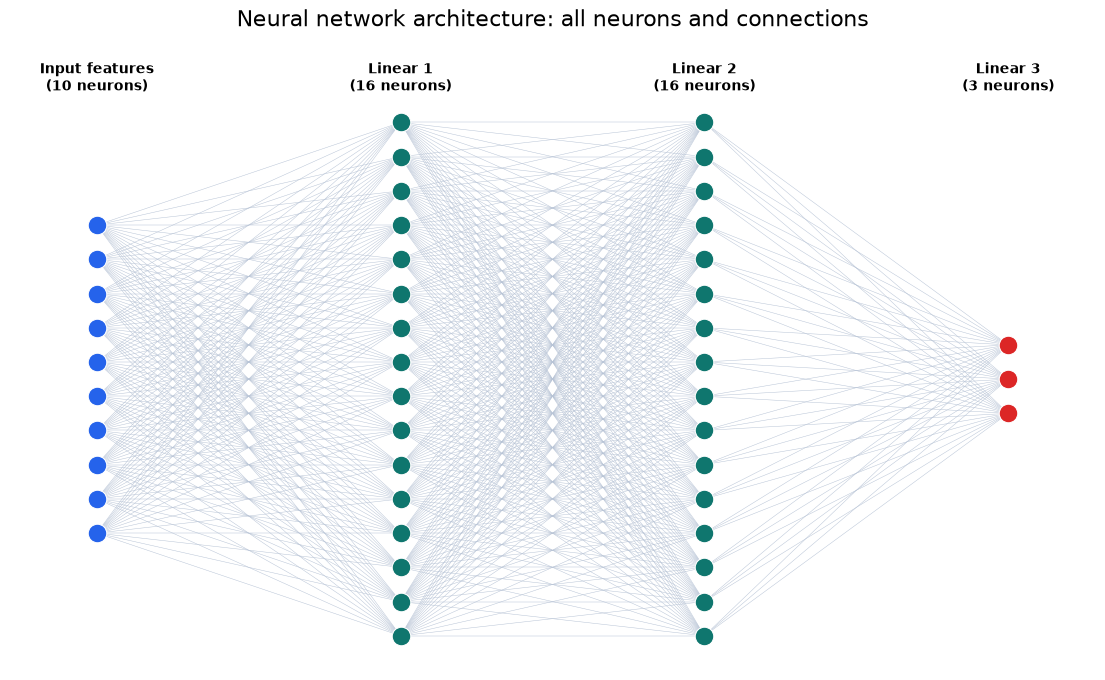

In [11]:
draw_network(network)


### Regressor training

In [12]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import RMSprop
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

EPOCHS = 5
# Create a synthetic dataset for regression
features, target = make_regression(n_features=10, n_samples=1000)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Transform the data into PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
        )

    def forward(self, x):
        x = self.sequential(x)
        return x

# Initialize the neural network
network = SimpleNeuralNet()

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = RMSprop(network.parameters())

# Define the data loader for training
train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Compile the model using the torch 2.0 optimizer
network = torch.compile(network)

# Train the neural network using backpropagation
for epoch in range(EPOCHS):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print("Epoch:", epoch + 1, "\tloss:", loss.item())
    
# Evaluate the model on the test set
with torch.no_grad():
    output = network(x_test)
    test_loss = float(criterion(output, y_test))
    print("Test MSE:", test_loss)

Epoch: 1 	loss: 10764.02734375
Epoch: 2 	loss: 1356.51025390625
Epoch: 3 	loss: 504.96636962890625
Epoch: 4 	loss: 199.11312866210938
Epoch: 5 	loss: 191.2083740234375
Test MSE: 162.2450714111328


### Making forecasts

In [13]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import RMSprop
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a synthetic dataset for binary classification
features, target = make_classification(n_classes=2, n_features=10, n_samples=1000)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)

# Set a fixed random seed
torch.manual_seed(0)
np.random.seed(0)

# Convert the data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.sequential(x)
        return x

# Initialize the neural network, loss criterion, and optimizer
network = SimpleNeuralNet()

# Define the loss criterion and optimizer
criterion = nn.BCELoss()
optimizer = RMSprop(network.parameters())

# Define the training data loader
train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Compile the network for improved performance
network = torch.compile(network)

# Train the neural network using backpropagation
epochs = 3
for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print("Epoch: ", epoch+1, "\tloss: ", loss.item())
    
# Evaluate the model on the test set
with torch.no_grad():
    predicted_class = network.forward(x_train).round()
    
predicted_class[0]

Epoch:  1 	loss:  0.19006989896297455
Epoch:  2 	loss:  0.14092369377613068
Epoch:  3 	loss:  0.03935524821281433


tensor([1.])

### Visualization of learning history

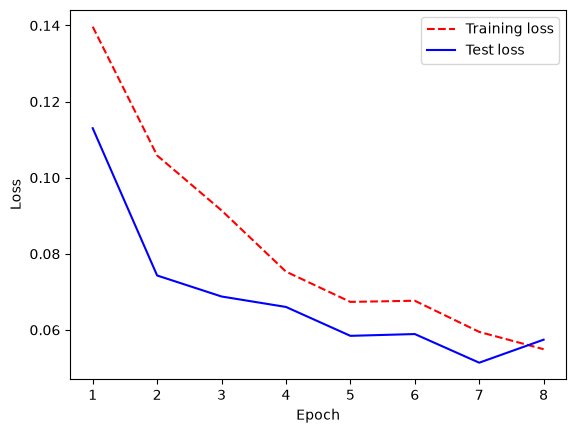

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import DataLoader, TensorDataset

# Create a synthetic dataset for binary classification
features, target = make_classification(
    n_classes=2, n_features=10, n_samples=1000, random_state=0
)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)

# Set a fixed random seed
torch.manual_seed(0)
np.random.seed(0)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.sequential(x)


# Initialize the neural network
network = SimpleNeuralNet()
criterion = nn.BCELoss()
optimizer = RMSprop(network.parameters())

train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

epochs = 8
train_losses = []
test_losses = []
for epoch in range(epochs):
    network.train()
    for data, target in train_loader:
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    network.eval()
    with torch.no_grad():
        train_output = network(x_train)
        train_loss = criterion(train_output, y_train).item()
        train_losses.append(train_loss)

        test_output = network(x_test)
        test_loss = criterion(test_output, y_test).item()
        test_losses.append(test_loss)

# Visualize the training and test losses over epochs
epoch_numbers = range(1, epochs + 1)
plt.plot(epoch_numbers, train_losses, "r--")
plt.plot(epoch_numbers, test_losses, "b-")
plt.legend(["Training loss", "Test loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epoch_numbers))
plt.show()

### Weight regularization to reduce overfitting

In [15]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import RMSprop
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a synthetic dataset for binary classification
features, target = make_classification(n_classes=2, n_features=10, n_samples=1000)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1)

# Set a fixed random seed
torch.manual_seed(0)
np.random.seed(0)

# Convert the data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.sequential(x)
        return x


# Initialize the neural network
network = SimpleNeuralNet()

# Define the loss criterion and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(network.parameters(), lr=1e-4, weight_decay=1e-5)

# Define the training data loader
train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Compile the network for improved performance
network = torch.compile(network)

# Train the neural network using backpropagation
epochs = 100
for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
# Evaluate the model on the test set
with torch.no_grad():
    output = network(x_test)
    test_loss = criterion(output, y_test)
    test_accuracy = (output.round() == y_test).float().mean()
    print("Test Loss:", test_loss.item(), "\tTest Accuracy:", test_accuracy.item())

Test Loss: 0.40308892726898193 	Test Accuracy: 0.9599999785423279


### Reducing overfitting through early stopping

In [16]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r".*is deprecated, use `isinstance\(treespec, TreeSpec\) and treespec.is_leaf\(\)` instead.*",
    category=Warning,
)
warnings.filterwarnings(
    "ignore",
    message=r"The 'train_dataloader' does not have many workers.*",
    category=UserWarning,
)

import numpy as np
import torch
import lightning as pl
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Create a synthetic dataset
features, target = make_classification(
    n_classes=2, n_features=10, n_samples=1000, random_state=0
)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)

# Set the random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)


class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.sequential(x)


class LightningNetwork(pl.LightningModule):
    def __init__(self, network):
        super().__init__()
        self.network = network
        self.criterion = nn.BCELoss()

    def training_step(self, batch, batch_idx):
        data, target = batch
        output = self.network(data)
        loss = self.criterion(output, target)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)


train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True, num_workers=0)

network = LightningNetwork(SimpleNeuralNet())
trainer = pl.Trainer(
    callbacks=[EarlyStopping(monitor="train_loss", mode="min", patience=3)],
    max_epochs=1000,
    logger=False,
    enable_checkpointing=False,
    log_every_n_steps=1,
)
trainer.fit(model=network, train_dataloaders=train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type            | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | network   | SimpleNeuralNet | 465    | train | 0    
1 | criterion | BCELoss         | 0      | train | 0    
--------------------------------------------------------------
465       Trainable params
0         Non-trainable params
465       Total params
0.002     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |          | 0/? [00:00<?, ?it/s]

### Reducing the effect of overfitting using the dropout method

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import RMSprop
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a synthetic dataset for binary classification
features, target = make_classification(n_classes=2, n_features=10, n_samples=1000)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)
# Set a fixed random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Convert the data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Dropout(0.1),  # Remove 10% of neurons
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.sequential(x)
    
# Initialize the neural network
network = SimpleNeuralNet()

# Define the loss criterion and optimizer
criterion = nn.BCELoss()
optimizer = RMSprop(network.parameters())

# Define the data loader
train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Compile the model using the torch 2.0 optimizer
network = torch.compile(network)

# Train the neural network using backpropagation
epochs = 3
for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print("Epoch:", epoch+1, "\tloss:", loss.item())
    
# Evaluate the model on the test set
with torch.no_grad():
    output = network(x_test)
    test_loss = criterion(output, y_test)
    test_accuracy = (output.round() == y_test).float().mean()
    print("Test Loss:", test_loss.item(), "\tTest Accuracy:", test_accuracy.item())

Epoch: 1 	loss: 0.20735646784305573
Epoch: 2 	loss: 0.20834866166114807
Epoch: 3 	loss: 0.25975286960601807
Test Loss: 0.1384032815694809 	Test Accuracy: 0.8999999761581421


### Saving the model's training progress

In [18]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import RMSprop
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a synthetic dataset for binary classification
features, target = make_classification(n_classes=2, n_features=10, n_samples=1000)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1)

# Set a fixed random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Dropout(0.1),  # Remove 10% of neurons
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.sequential(x)
    
# Initialize the neural network
network = SimpleNeuralNet()

# Define the loss function and optimization
criterion = nn.BCELoss()
optimizer = RMSprop(network.parameters())

# Define the data loader
train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Compile the model using the new torch 2.0 compile API
network = torch.compile(network)

# Train the neural network
epochs = 5
for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    # Save one checkpoint after all batches in the epoch are complete.
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": network.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss.item(),
    }
    torch.save(checkpoint, "model.pt")
    print("Epoch:", epoch + 1, "\tloss:", loss.item())

Epoch: 1 	loss: 0.20735646784305573
Epoch: 2 	loss: 0.20834866166114807
Epoch: 3 	loss: 0.25975286960601807
Epoch: 4 	loss: 0.1492830067873001
Epoch: 5 	loss: 0.20664513111114502


### Setting up neural networks

In [19]:
import numpy as np
import torch
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

# Create a synthetic dataset for binary classification
features, target = make_classification(n_classes=2, n_features=10, n_samples=1000)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)
# Set a fixed random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self, layer_size_1=10, layer_size_2=10):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, layer_size_1),
            torch.nn.ReLU(),
            torch.nn.Linear(layer_size_1, layer_size_2),
            torch.nn.ReLU(),
            torch.nn.Linear(layer_size_2, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.sequential(x)


config = {
    "layer_size_1": tune.sample_from(lambda _: 2 ** np.random.randint(2, 9)),
    "layer_size_2": tune.sample_from(lambda _: 2 ** np.random.randint(2, 9)),
    "lr": tune.loguniform(1e-4, 1e-1),
}

scheduler = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=3,
    grace_period=1,
    reduction_factor=2,
)

reporter = CLIReporter(
    parameter_columns=["layer_size_1", "layer_size_2", "lr"],
    metric_columns=["loss"],
)


# Train one model for each hyperparameter configuration.
def train_model(config, epochs=3):
    network = SimpleNeuralNet(config["layer_size_1"], config["layer_size_2"])
    criterion = nn.BCELoss()
    optimizer = optim.SGD(network.parameters(), lr=config["lr"], momentum=0.9)
    train_data = TensorDataset(x_train, y_train)
    train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

    for epoch in range(epochs):
        network.train()
        for data, target in train_loader:
            optimizer.zero_grad()
            output = network(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        # Ray Tune 2.x expects a metrics dictionary.
        tune.report({"loss": loss.item()})


result = tune.run(
    train_model,
    resources_per_trial={"cpu": 8},
    config=config,
    num_samples=1,
    scheduler=scheduler,
    progress_reporter=reporter,
)

best_trial = result.get_best_trial("loss", "min", "last")
print("Best trial config: {}".format(best_trial.config))
print("Best trial final validation loss: {}".format(best_trial.last_result["loss"]))

best_trained_model = SimpleNeuralNet(
    best_trial.config["layer_size_1"], best_trial.config["layer_size_2"]
)

2026-08-20 20:44:13,455	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-20 20:44:14,246	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2026-08-20 20:44:14,247	INFO tune.py:621 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


== Status ==
Current time: 2026-08-20 20:44:14 (running for 00:00:00.13)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 2.000: None | Iter 1.000: None
Logical resource usage: 8.0/16 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/session_2026-08-20_20-44-10_980219_250396/artifacts/2026-08-20_20-44-14/train_model_2026-08-20_20-44-14/driver_artifacts
Number of trials: 1/1 (1 PENDING)
+-------------------------+----------+-------+----------------+----------------+------------+
| Trial name              | status   | loc   |   layer_size_1 |   layer_size_2 |         lr |
|-------------------------+----------+-------+----------------+----------------+------------|
| train_model_fec28_00000 | PENDING  |       |            128 |              4 | 0.00443038 |
+-------------------------+----------+-------+----------------+----------------+------------+




Trial name,loss
train_model_fec28_00000,0.682508


2026-08-20 20:44:17,591	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/max/ray_results/train_model_2026-08-20_20-44-14' in 0.0025s.
2026-08-20 20:44:17,597	INFO tune.py:1039 -- Total run time: 3.35 seconds (3.30 seconds for the tuning loop).


== Status ==
Current time: 2026-08-20 20:44:17 (running for 00:00:03.30)
Using AsyncHyperBand: num_stopped=1
Bracket: Iter 2.000: -0.6945991516113281 | Iter 1.000: -0.6901111602783203
Logical resource usage: 8.0/16 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/session_2026-08-20_20-44-10_980219_250396/artifacts/2026-08-20_20-44-14/train_model_2026-08-20_20-44-14/driver_artifacts
Number of trials: 1/1 (1 TERMINATED)
+-------------------------+------------+----------------------+----------------+----------------+------------+----------+
| Trial name              | status     | loc                  |   layer_size_1 |   layer_size_2 |         lr |     loss |
|-------------------------+------------+----------------------+----------------+----------------+------------+----------|
| train_model_fec28_00000 | TERMINATED | 192.168.0.173:254658 |            128 |              4 | 0.00443038 | 0.682508 |
+-------------------------+------------+----------------------+----------------+----------------+---

### Visualization of a neural network

In [20]:
import shutil

import numpy as np
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import DataLoader, TensorDataset
from torchviz import make_dot

# Create a synthetic dataset for binary classification
features, target = make_classification(
    n_classes=2, n_features=10, n_samples=1000, random_state=0
)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1
)

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(features_train).float()
y_train = torch.from_numpy(target_train).float().view(-1, 1)
x_test = torch.from_numpy(features_test).float()
y_test = torch.from_numpy(target_test).float().view(-1, 1)

# Define a simple neural network using 'Sequential'
class SimpleNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(10, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.sequential(x)


# Initialize the neural network
network = SimpleNeuralNet()
criterion = nn.BCELoss()
optimizer = RMSprop(network.parameters())

train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

# Train the model before tracing its computation graph.
epochs = 3
for epoch in range(epochs):
    network.train()
    for data, target in train_loader:
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

# Build and save the computation graph for one representative sample.
network.eval()
sample_output = network(x_test[:1])
graph = make_dot(sample_output, params=dict(network.named_parameters()))
if shutil.which("dot"):
    graph.render("simple_neural_network", format="png", cleanup=True)
    print("Saved computation graph to simple_neural_network.png")
else:
    print("Graphviz executable 'dot' is not installed.")
    print("Install it with: sudo apt install graphviz")

Saved computation graph to simple_neural_network.png
